# Exploratory Data Analysis  
## US Accidents Dataset

У цьому ноутбуці проведено exploratory data analysis (EDA) вибірки датасету US Accidents.

Метою аналізу є дослідження основних закономірностей ДТП, аналіз факторів, пов’язаних із severity аварій, а також виявлення часових, погодних і географічних патернів.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    '/Users/veronika/Documents/US_Accidents_Project/data/processed/cleaned_us_accidents.csv'
)

### 1. Dataset Overview

In [3]:
print("Датасет містить:")
print(f"Рядків: {df.shape[0]:,}")
print(f"Колонок: {df.shape[1]}")

Датасет містить:
Рядків: 386,179
Колонок: 40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386179 entries, 0 to 386178
Data columns (total 40 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 386179 non-null  object 
 1   Severity           386179 non-null  int64  
 2   Start_Time         386179 non-null  object 
 3   End_Time           386179 non-null  object 
 4   Start_Lat          386179 non-null  float64
 5   Start_Lng          386179 non-null  float64
 6   Street             386179 non-null  object 
 7   City               386179 non-null  object 
 8   County             386179 non-null  object 
 9   State              386179 non-null  object 
 10  Timezone           386179 non-null  object 
 11  Humidity(%)        386179 non-null  float64
 12  Wind_Direction     386179 non-null  object 
 13  Weather_Condition  386179 non-null  object 
 14  Amenity            386179 non-null  bool   
 15  Bump               386179 non-null  bool   
 16  Cr

In [5]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,State,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
0,A-75728,2,2016-11-28 16:23:04,2016-11-28 17:07:39,34.027828,-118.211700,US-101 N,Los Angeles,Los Angeles,CA,...,2016,Monday,False,16.722222,14.444444,0.016093,16.0934,8.046700,0.0,1009.982526
1,A-80191,3,2016-09-28 12:33:15,2016-09-28 13:02:57,33.937790,-117.556152,6th St,Norco,Riverside,CA,...,2016,Wednesday,False,33.277778,23.333333,0.000000,16.0934,5.632690,0.0,1013.030763
2,A-19865,3,2016-09-13 20:16:23,2016-09-13 20:46:23,38.553600,-121.690643,I-80 E,Davis,Yolo,CA,...,2016,Tuesday,False,19.000000,23.333333,0.000000,16.0934,9.334172,0.0,1014.046842
3,A-76706,3,2016-09-13 10:07:38,2016-09-13 10:37:38,33.965294,-117.326668,I-215 S,Riverside,Riverside,CA,...,2016,Tuesday,False,18.277778,23.333333,0.000000,16.0934,9.656040,0.0,1014.385535
4,A-92998,3,2016-08-27 17:56:49,2016-08-27 18:26:49,33.872711,-118.284805,Artesia Fwy E,Gardena,Los Angeles,CA,...,2016,Saturday,True,22.222222,23.888889,0.000000,16.0934,14.805928,0.0,1013.708149


### 2. Severity Analysis

У цьому блоці аналізується розподіл рівнів severity, частка severe accidents, а також зв’язок severity із погодними та географічними факторами.

In [6]:
df['Severity'].value_counts().sort_index()
df['Severity'].value_counts(normalize=True).sort_index() * 100

Severity
1     0.857892
2    79.698534
3    16.784186
4     2.659389
Name: proportion, dtype: float64

In [7]:
df['is_severe'] = df['Severity'].apply(lambda x: 1 if x >= 3 else 0)

In [8]:
total_accidents = df['ID'].count()
avg_severity = df['Severity'].mean()
median_severity = df['Severity'].median()
severe_rate = df['is_severe'].mean() * 100

print(f"Загальна кількість аварій: {total_accidents}")
print(f"Середня тяжкість аварій: {avg_severity:.3f}")
print(f"Медіана тяжкості аварій: {median_severity}")
print(f"Частка тяжких аварій: {severe_rate:.2f} %")

Загальна кількість аварій: 386179
Середня тяжкість аварій: 2.212
Медіана тяжкості аварій: 2.0
Частка тяжких аварій: 19.44 %


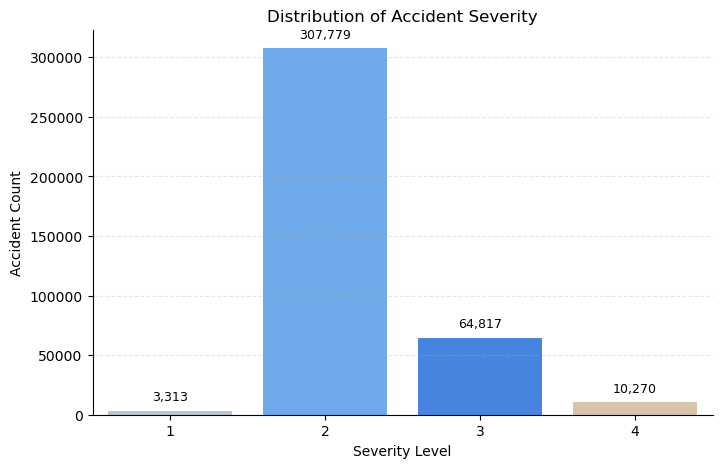

In [9]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Severity',
    hue='Severity',
    palette=["#B8C7D9", "#5DA9FF", "#2D7FF9", "#E0C3A3"],
    legend=False
)

plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Accident Count')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.show()

Висновок:

Більшість аварій у датасеті належать до рівня severity 2, тоді як аварії з високою severity (рівні 3 та 4) трапляються значно рідше. Це свідчить про те, що основна частина зафіксованих ДТП має помірний рівень серйозності, а критичні аварії становлять меншу частку від загальної кількості випадків.

In [10]:
# додаю колонку для визначення чи тяжка аварія, чи ні
# для severity = 1-2 (Non-severe), 3-4 (Severe)
df['severity_group'] = df['Severity'].apply(
    lambda x: 'Severe' if x >= 3 else 'Non-severe'
)
df['severity_group'].value_counts(normalize=True) * 100

severity_group
Non-severe    80.556426
Severe        19.443574
Name: proportion, dtype: float64

Проаналізую середній рівень severity у різних штатах для виявлення регіонів із підвищеним рівнем серйозності ДТП.

In [11]:
# Середня тяжкість по штатам

severity_by_state = (
    df.groupby('State')
    .agg(
        accident_count=('ID', 'count'),
        avg_severity=('Severity', 'mean')
    )
    .reset_index()
)

severity_by_state = (
    severity_by_state[severity_by_state['accident_count'] >= 100]
    .sort_values('avg_severity', ascending=False)
)

severity_by_state.head(10)

,State,accident_count,avg_severity
9,GA,8608,2.502788
46,WI,1738,2.490794
15,KY,1607,2.467953
37,RI,843,2.454330
4,CO,4398,2.453615
10,IA,1328,2.433735
13,IN,3434,2.389342
22,MO,3867,2.386346
12,IL,8301,2.383568
30,NM,509,2.379175


Висновок:

Найвищий середній рівень severity спостерігається у штатах Georgia, Wisconsin та Kentucky. Водночас деякі штати мають відносно невелику кількість аварій, але демонструють високий average severity, що може свідчити про більш небезпечні умови дорожнього руху або складні погодні фактори.


In [12]:
# Середня тяжкість за погодними умовами

severity_by_weather = (
    df.groupby('Weather_Condition')
    .agg(
        accident_count=('ID', 'count'),
        avg_severity=('Severity', 'mean')
    )
    .reset_index()
)

severity_by_weather = (
    severity_by_weather[severity_by_weather['accident_count'] >= 100]
    .sort_values('avg_severity', ascending=False)
)

severity_by_weather.head(10)

,Weather_Condition,accident_count,avg_severity
57,Light Thunderstorms and Rain,262,2.454198
103,Thunderstorm,225,2.404444
64,Overcast,19141,2.387232
40,Light Freezing Rain,168,2.380952
78,Scattered Clouds,10182,2.377922
4,Clear,40586,2.366136
87,Snow,771,2.299611
8,Drizzle,271,2.280443
70,Rain,4112,2.267267
51,Light Snow,6389,2.256535


Висновок

Найвищий середній рівень тяжкості спостерігається під час грозових погодних умов, зокрема Thunderstorm та Light Thunderstorms and Rain. Водночас навіть за умов Clear та Overcast середній рівень тяжкості залишається відносно високим, що свідчить про те, що серйозність ДТП залежить не лише від погоди, але й від інших факторів дорожнього руху.

In [13]:
# Visibility and Severity

# видаляємо екстримальні outliers видимості за 99 персентилем

visibility_limit = df['Visibility(km)'].quantile(0.99)

visibility_filtered = df[
    df['Visibility(km)'] <= visibility_limit
]

print(f"Поріг 99-го перцентиля для visibility {visibility_limit:.2f} km")

Поріг 99-го перцентиля для visibility 16.09 km


In [14]:
palette = {
    1: "#A9D0FF",
    2: "#4F9DFF",
    3: "#0066FF",
    4: "#111111"
}

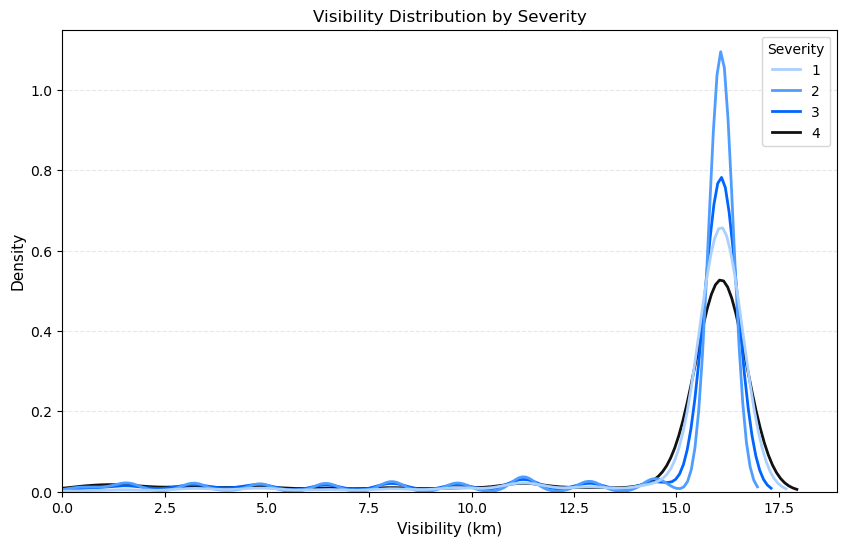

In [15]:
# KDE-графік: розподіл visibility залежно від severity

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=visibility_filtered,
    x='Visibility(km)',
    hue='Severity',
    common_norm=False,
    palette=palette,
    linewidth=2
)

plt.title('Visibility Distribution by Severity')

plt.xlabel('Visibility (km)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlim(left=0)

plt.show()

Висновок

Найбільша концентрація аварій усіх рівнів тяжності спостерігається за високої видимості. Водночас для тяжкі аварії (severity 3–4) розподіл є більш широким, що може свідчити про більший вплив поганої видимості на серйозність ДТП.

### 3. Weather Analysis

У цьому блоці аналізуються погодні умови, пов’язані з дорожньо-транспортними пригодами, а також їхній потенційний вплив на умови дорожнього руху.

In [16]:
# Найпоширеніші погодні умови

top_weather = (
    df['Weather_Condition']
    .value_counts()
    .head(10)
    .reset_index()
)

top_weather.columns = ['Weather_Condition', 'Accident_Count']
top_weather

,Weather_Condition,Accident_Count
0,Fair,136121
1,Mostly Cloudy,50855
2,Cloudy,41451
3,Clear,40586
4,Partly Cloudy,34738
5,Overcast,19141
6,Light Rain,17651
7,Scattered Clouds,10182
8,Light Snow,6389
9,Fog,4979


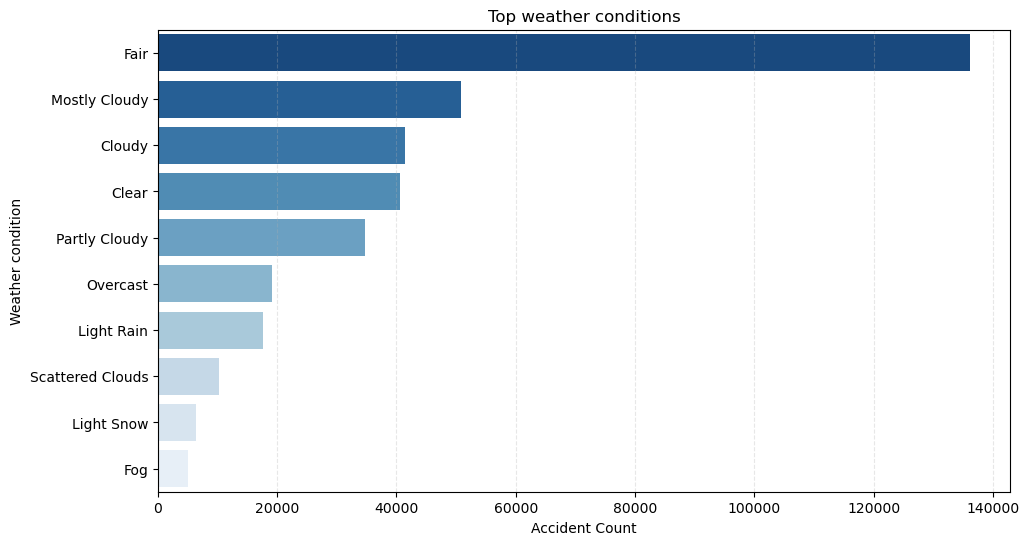

In [17]:
# візуалізація найпоширеніших погодних умов

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_weather,
    x='Accident_Count',
    y='Weather_Condition',
    hue='Weather_Condition',
    palette='Blues_r',
    legend=False
)

plt.title('Top weather conditions')
plt.xlabel('Accident Count')
plt.ylabel('Weather condition')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Висновок

Найбільша кількість аварій трапляється за стандартних погодних умов, зокрема Fair, Mostly Cloudy, Cloudy та Clear. Це свідчить про те, що більшість поїздок здійснюється саме за нормальної погоди, тому навіть без екстремальних погодних умов фіксується велика кількість ДТП.

In [18]:
# precipitation аналіз

df['Temperature(C)'].describe()

count    386179.000000
mean         16.480405
std          10.505465
min         -67.222222
25%           9.444444
50%          17.777778
75%          24.444444
max          60.000000
Name: Temperature(C), dtype: float64

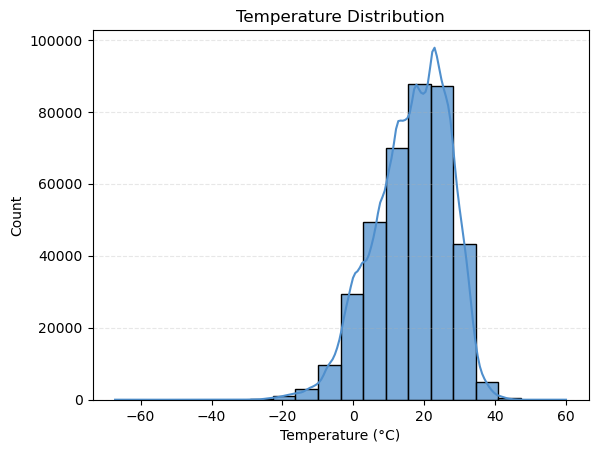

In [19]:
# візуалізація розподілу температури

sns.histplot(
    data=df,
    x='Temperature(C)',
    bins=20,
    kde=True,
    color='#4F8FCD',
    edgecolor='black',
    alpha=0.75
)

plt.title('Temperature Distribution',)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Висновок

Найбільша кількість аварій трапляється за помірних температур, переважно в діапазоні від 10°C до 25°C. Розподіл температур є близьким до нормального без значної кількості екстремальних значень.

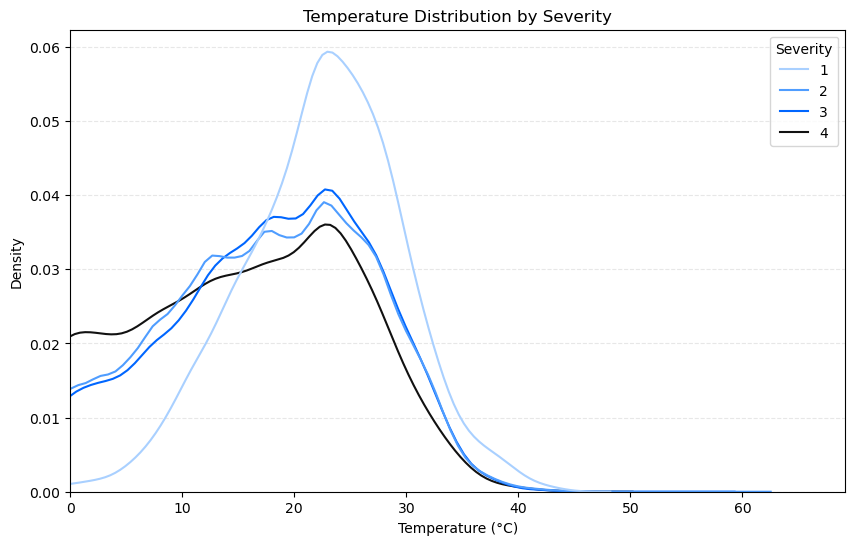

In [20]:
# KDE-графік: розподіл температури залежно від тяжкості аварій

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='Temperature(C)',
    hue='Severity',
    common_norm=False,
    palette=palette
)

plt.title('Temperature Distribution by Severity')

plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlim(left=0)

plt.show()

Висновок

Розподіл температур для різних рівнів тяжкості є досить схожим, однак тяжкі ДТП (severity 4) дещо частіше трапляються за нижчих температур. Найбільша концентрація аварій усіх рівнів спостерігається в діапазоні приблизно від 15°C до 30°C.

In [21]:
# аналіз фактору видимості 

# Створення visibility groups

df['visibility_group'] = pd.cut(
    df['Visibility(km)'],
    bins=[0, 2, 5, 10, 20],
    labels=[
        'Low',
        'Moderate',
        'Good',
        'High'
    ]
)

In [22]:
# Top weather conditions

top_weather_conditions = (
    df['Weather_Condition']
    .value_counts()
    .head(8)
    .index
)

In [23]:
# Pivot table для heatmap

visibility_weather_pivot = (
    df[df['Weather_Condition'].isin(top_weather_conditions)]
    .pivot_table(
        values='Severity',
        index='Weather_Condition',
        columns='visibility_group',
        aggfunc='mean'
    )
)

/var/folders/m5/b983szfn5sv1rtcscwh5hkwm0000gn/T/ipykernel_16367/2684475544.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


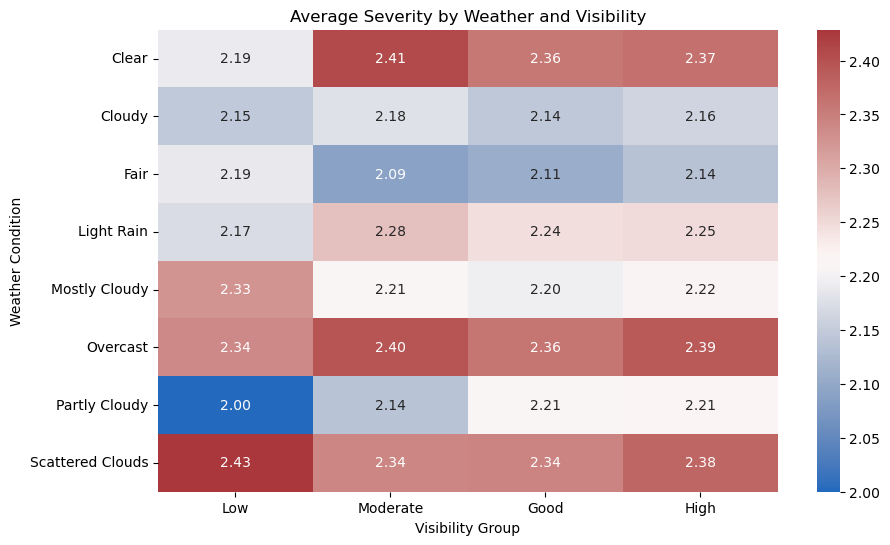

In [24]:
# Heatmap: weather × visibility groups

plt.figure(figsize=(10, 6))

sns.heatmap(
    visibility_weather_pivot,
    annot=True,
    fmt='.2f',
    cmap='vlag'
)

plt.title('Average Severity by Weather and Visibility')
plt.xlabel('Visibility Group')
plt.ylabel('Weather Condition')

plt.show()

Висновок

Найвищий середній рівень тяжкості спостерігається за умов низької або помірної видимості у поєднанні з такими погодними умовами, як Scattered Clouds, Overcast та Clear. Загалом heatmap демонструє, що тяжкість залежить не лише від видимості, але й від комбінації погодних факторів.

In [25]:
# аналіз швидкості вітру

df['Wind_Speed(kmh)'].describe()

count    386179.000000
mean         12.261750
std           8.225662
min           0.000000
25%           8.046700
50%          11.265380
75%          16.093400
max         271.978460
Name: Wind_Speed(kmh), dtype: float64

In [26]:
# обрізаємо екстремальні значення через 99-й перцентиль

wind_limit = df['Wind_Speed(kmh)'].quantile(0.99)

wind_filtered = df[
    df['Wind_Speed(kmh)'] <= wind_limit
]

print(f'Поріг 99-го перцентиля для wind speed: {wind_limit:.2f} km/h')

Поріг 99-го перцентиля для wind speed: 37.01 km/h


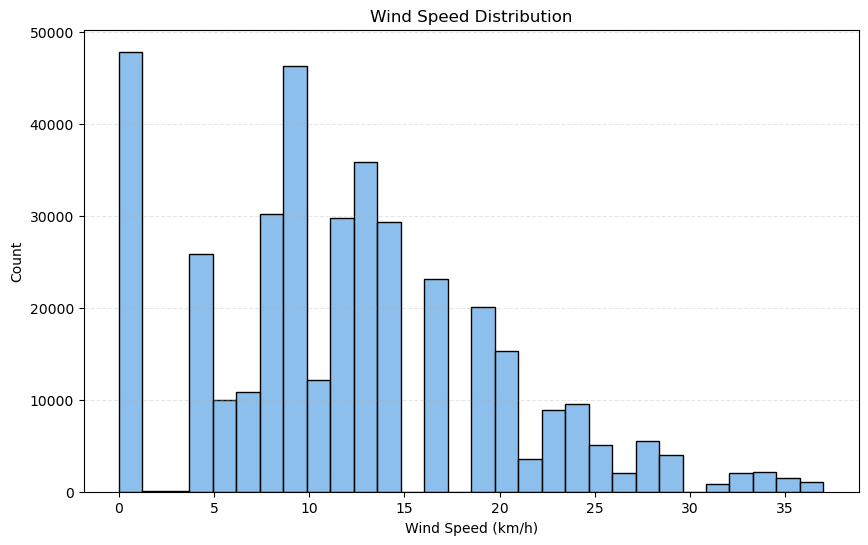

In [27]:
# розподіл швидкості вітру

plt.figure(figsize=(10, 6))

sns.histplot(
    data=wind_filtered,
    x='Wind_Speed(kmh)',
    bins=30,
    color='#6FAFE7',
    edgecolor='black',
    alpha=0.8
)

plt.title('Wind Speed Distribution')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Count')

plt.grid(axis='y', linestyle='--', alpha=0.3)

Висновок

Більшість аварій трапляється за низької або помірної швидкості вітру. Розподіл має правосторонній хвіст, однак випадки з дуже високою швидкістю вітру зустрічаються відносно рідко.

### 4. Multi-Factor Analysis

У цьому блоці аналізуються комбінації факторів, пов’язаних із дорожньо-транспортними пригодами, для виявлення сценаріїв із підвищеним рівнем ризику.

In [28]:
# Створення visibility groups

df['visibility_group'] = pd.cut(
    df['Visibility(km)'],
    bins=[0, 1, 3, 5, 10, 100],
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'Good',
        'High'
    ]
)

In [29]:
# створення day/night groups

df['day_period'] = df['Sunrise_Sunset'].replace({
    'Day': 'Day',
    'Night': 'Night'
})

In [30]:
# створення road feature category

import numpy as np

df['road_feature'] = np.select(
    [
        df['Junction'] == True,
        df['Traffic_Signal'] == True,
        df['Crossing'] == True,
        df['Stop'] == True
    ],
    [
        'Junction',
        'Traffic Signal',
        'Crossing',
        'Stop'
    ],
    default='No Feature'
)

In [31]:
multi_factor_summary = (
    df.groupby([
        'Weather_Condition',
        'visibility_group',
        'day_period',
        'road_feature'
    ])
    .agg(
        accident_count=('ID', 'count'),
        avg_severity=('Severity', 'mean')
    )
    .reset_index()
)

/var/folders/m5/b983szfn5sv1rtcscwh5hkwm0000gn/T/ipykernel_16367/2433744969.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([


In [32]:
# фільтрація сценаріїв з достатньою кількістю аварій

multi_factor_summary = (
    multi_factor_summary[
        multi_factor_summary['accident_count'] >= 300
    ]
)

In [33]:
# сортування сценаріїв за severity та кількістю аварій

multi_factor_summary = (
    multi_factor_summary
    .sort_values(
        ['avg_severity', 'accident_count'],
        ascending=[False, False]
    )
)

In [34]:
top_scenarios = multi_factor_summary.head(10)
top_scenarios

,Weather_Condition,visibility_group,day_period,road_feature,accident_count,avg_severity
3246,Overcast,High,Night,Junction,527,2.652751
246,Clear,High,Night,Junction,1019,2.594701
3947,Scattered Clouds,High,Night,No Feature,1138,2.554482
3247,Overcast,High,Night,No Feature,3523,2.524269
247,Clear,High,Night,No Feature,7893,2.503737
3237,Overcast,Good,Night,No Feature,334,2.491018
3241,Overcast,High,Day,Junction,918,2.482571
3941,Scattered Clouds,High,Day,Junction,680,2.477941
3222,Overcast,Medium,Day,No Feature,448,2.459821
3942,Scattered Clouds,High,Day,No Feature,5264,2.445289


In [35]:
# Pivot table для heatmap:

scenario_heatmap = (
    df.pivot_table(
        values='Severity',
        index='visibility_group',
        columns='day_period',
        aggfunc='mean'
    )
)

/var/folders/m5/b983szfn5sv1rtcscwh5hkwm0000gn/T/ipykernel_16367/2184941311.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


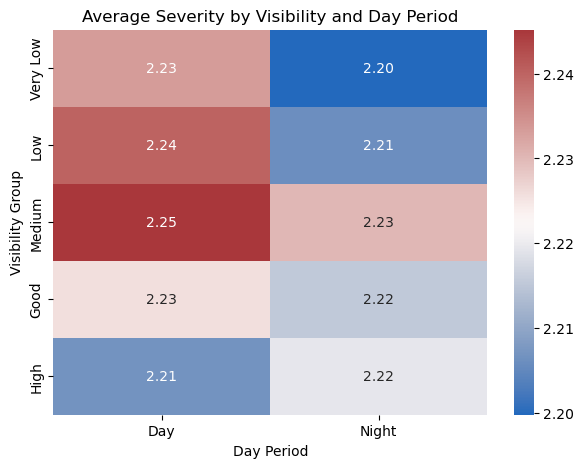

In [36]:
# Heatmap average severity

plt.figure(figsize=(7, 5))

sns.heatmap(
    scenario_heatmap,
    annot=True,
    fmt='.2f',
    cmap='vlag'
)

plt.title('Average Severity by Visibility and Day Period',)
plt.xlabel('Day Period')
plt.ylabel('Visibility Group')

plt.show()

Висновок

Мульти-факторний аналіз показує, що найвищий середній рівень тяжкості ДТП спостерігається переважно в нічний період у поєднанні з такими факторами, як Junction, Overcast та Clear weather conditions. Найризикованіші сценарії також часто пов’язані з низькою видимістю, що свідчить про те, що серйозність ДТП залежить не лише від погодних умов або видимості, але й від особливостей дорожньої інфраструктури та поведінки водіїв.